# Model Interpretability

In [15]:
import os
from datetime import datetime
from pathlib import Path

import boto3
import numpy as np
import pandas as pd
import shap
from dotenv import load_dotenv

In [2]:
_ = shap.initjs()

In [3]:
PROJ_ROOT = Path.cwd().parent

In [4]:
assert load_dotenv(dotenv_path=PROJ_ROOT.parent / ".env")

In [5]:
import cc_churn.explanation as shexp
import cc_churn.visualization as vzu
import r2.io_utils as r2io
from utils.df_utils import show_df

## About

Provide model interpredation for predicted churners and non-churners, among all available customers' data.

## User Inputs

In [6]:
# R2 data bucket details
# # name of train data key (file) in private R2 bucket
r2_key_train = "train_data.parquet.gzip"
# # name of validation data key (file) in private R2 bucket
r2_key_val = "validation_data.parquet.gzip"
# # name of test data key (file) in private R2 bucket
r2_key_test = "test_data.parquet.gzip"

# # datatypes for categorical and ordinal columns
# dtypes_ordinals = {
#     "gender": "string[pyarrow]",
#     "income_category": "string[pyarrow]",
#     "education_level": "string[pyarrow]",
# }
# dtypes_categoricals = {
#     "marital_status": "category",
#     "card_category": "category",
# }

# trained model prefix
key_prefix = "2026-04-13/best_model__"

# predictions prefix
r2_key_pred = "2026-04-13/all_predictions__"
cols_predictions = ["clientnum", "y_pred", "y_pred_proba"]

r2_key_pred_bm_savings = (
    "2026-04-13/at_risk_customers_with_business_metrics_savings__"
)

label = "is_churned"

In [7]:
account_id = os.getenv("ACCOUNT_ID")
access_key_id = os.getenv("ACCESS_KEY_ID_USER2")
secret_access_key = os.getenv("SECRET_ACCESS_KEY_USER2")
bucket_name = os.getenv("BUCKET_NAME")

s3_client = boto3.client(
    "s3",
    endpoint_url=f"https://{account_id}.r2.cloudflarestorage.com",
    aws_access_key_id=access_key_id,
    aws_secret_access_key=secret_access_key,
    region_name="auto",
)

## Load Data

### Trained Model

Load pipeline

In [8]:
%%time
pipe_best = r2io.joblib_load_from_r2(s3_client, bucket_name, key_prefix)
pipe_best

CPU times: user 83.5 ms, sys: 17.6 ms, total: 101 ms
Wall time: 372 ms


,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...m_state=42))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",make_scorer(a...hod='predict')
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",StratifiedKFo... shuffle=True)
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectivel

Extract transformer and preprocessor as separate pipeline and model

In [9]:
pipe_transf_pre = pipe_best.estimator_[:-1]
model = pipe_best.estimator_.named_steps["clf"]

Get the best features, that were also preprocessed by the best pipeline (`pipe_best`) above

In [10]:
best_features = (
    pipe_transf_pre.named_steps["pre"]
    .named_transformers_["num"]
    .feature_names_in_.tolist()
)

### Predictions

Load scenarios (using estimated savings) from predictions

In [21]:
%%time
df_scenarios = r2io.pandas_read_filtered_parquets_r2(
    s3_client,
    bucket_name,
    r2_key_pred_bm_savings,
    ["clientnum", "value_tier", "risk_level", "scenario"],
)
_ = show_df(df_scenarios)
with pd.option_context("display.max_columns", None):
    display(df_scenarios.head(1))

,num_missing,num_unique,dtype
clientnum,0,962,int32[pyarrow]
value_tier,0,3,"dictionary<values=string, indices=int8, ordere..."
risk_level,0,3,"dictionary<values=string, indices=int8, ordere..."
scenario,0,2,int64[pyarrow]


Shape: 1,362 rows X 4 columns, Memory Usage: 19.607 KB


,clientnum,value_tier,risk_level,scenario
0,710178558,Platinum,High,1


CPU times: user 45 ms, sys: 924 μs, total: 45.9 ms
Wall time: 191 ms


Load predictions for each customer in all available data

In [22]:
%%time
df = (
    pd.concat(
        [
            r2io.pandas_read_parquet_r2(s3_client, bucket_name, k)
            for k in [r2_key_train, r2_key_val, r2_key_test]
        ]
    ).merge(
        r2io.pandas_read_filtered_parquets_r2(
            s3_client, bucket_name, r2_key_pred, cols_predictions
        ),
        on="clientnum",
        how="left",
    )
)
_ = show_df(df)
with pd.option_context("display.max_columns", None):
    display(df.head(1))

,num_missing,num_unique,dtype
clientnum,0,10127,int32[pyarrow]
is_churned,0,2,int8[pyarrow]
customer_age,0,45,int8[pyarrow]
gender,0,2,"dictionary<values=string, indices=int8, ordere..."
dependent_count,0,6,int8[pyarrow]
education_level,0,7,"dictionary<values=string, indices=int8, ordere..."
marital_status,0,4,"dictionary<values=string, indices=int8, ordere..."
income_category,0,6,"dictionary<values=string, indices=int8, ordere..."
card_category,0,4,"dictionary<values=string, indices=int8, ordere..."
months_on_book,0,44,int16[pyarrow]


Shape: 10,127 rows X 23 columns, Memory Usage: 884.535 KB


,clientnum,is_churned,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,num_products,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolv_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,y_pred,y_pred_proba
0,714283458,0,40,M,2,College,Single,$80K - $120K,Blue,36,5,1,4,14544.0,0.0,14544.0,0.768,4064.0,92,0.769,0.0,False,0.005326


CPU times: user 111 ms, sys: 17.7 ms, total: 128 ms
Wall time: 476 ms


## Separate Features from Target

In [23]:
X = df.drop(columns=[label])
y = df[label]

Get the features that were not used in training for the best pipeline above

In [24]:
features_non_preprocessed = list(set(list(X)) - set(best_features))

## Transform Data

### Non-Numerical Features with Rare Categories

This custom category combining transformer is applied below to all data

In [25]:
%%time
# train custom transformer and preprocessor on data
_ = pipe_transf_pre.fit(X)

# use trained pipeline to get column names after transformation & preprocessing
columns_transformed = list(
    pipe_transf_pre.get_feature_names_out(input_features=list(X)).tolist()
)

# apply trained transformer to perform category grouping on all data
X_transformed_preprocessed = pd.DataFrame(
    pipe_transf_pre.transform(X),
    columns=columns_transformed,
    index=X.index,
)
_ = show_df(X_transformed_preprocessed)

,num_missing,num_unique,dtype
months_on_book,0,44,float64
num_products,0,6,float64
months_inactive_12_mon,0,7,float64
contacts_count_12_mon,0,7,float64
total_amt_chng_q4_q1,0,1158,float64
total_trans_amt,0,5033,float64
total_trans_ct,0,126,float64
total_ct_chng_q4_q1,0,830,float64
credit_limit,0,6205,float64
total_revolv_bal,0,1974,float64


Shape: 10,127 rows X 10 columns, Memory Usage: 810.292 KB
CPU times: user 49.2 ms, sys: 65 μs, total: 49.3 ms
Wall time: 48.6 ms


### Pre-Process Numerical Features

Combine non-pre processed features, pre-processed numerical features and the true label for all customers

In [26]:
%%time
df_transf_pre = pd.concat(
    [X[features_non_preprocessed], X_transformed_preprocessed, y.rename("y")],
    axis=1,
)[list(X)+['y']]

CPU times: user 3.41 ms, sys: 40 μs, total: 3.45 ms
Wall time: 3.09 ms


In [28]:
%%time
df_scenarios_transf_pre = df_transf_pre.merge(
    df_scenarios[["clientnum", "risk_level", "value_tier", "scenario"]],
    on=["clientnum"],
    how="inner",
)
with pd.option_context("display.max_columns", None):
    display(df_scenarios_transf_pre.head(1))

,clientnum,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,num_products,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolv_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,y_pred,y_pred_proba,y,risk_level,value_tier,scenario
0,714022833,42,F,2,Graduate,Single,$40K - $60K,Silver,0.44186,0.6,0.5,0.5,0.49794,0.0,17909.0,0.066235,0.304162,0.372093,0.131125,0.0,True,0.989389,1,High,Silver,2


## Model Interpretability

### Predicted Churners

Get SHAP values (`shap_values`) and SHAP explanation object (`shap_explainer_values_*`) for the predicted churners

In [30]:
%%time
_, shap_explainer_values_pc = shexp.get_shap_values(
    model, df_transf_pre.query("y_pred == 1")[best_features]
)

CPU times: user 162 ms, sys: 968 μs, total: 163 ms
Wall time: 163 ms


Plot SHAP summary subplots consisting of

1. (LHS) [beeswarm plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html#A-simple-beeswarm-summary-plot) that shows how the most important features impact the model's predictions for churners
2. (RHS) [bar plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html#Global-bar-plot) showing the global feature importance, across all predicted churners

CPU times: user 108 ms, sys: 4.99 ms, total: 113 ms
Wall time: 112 ms


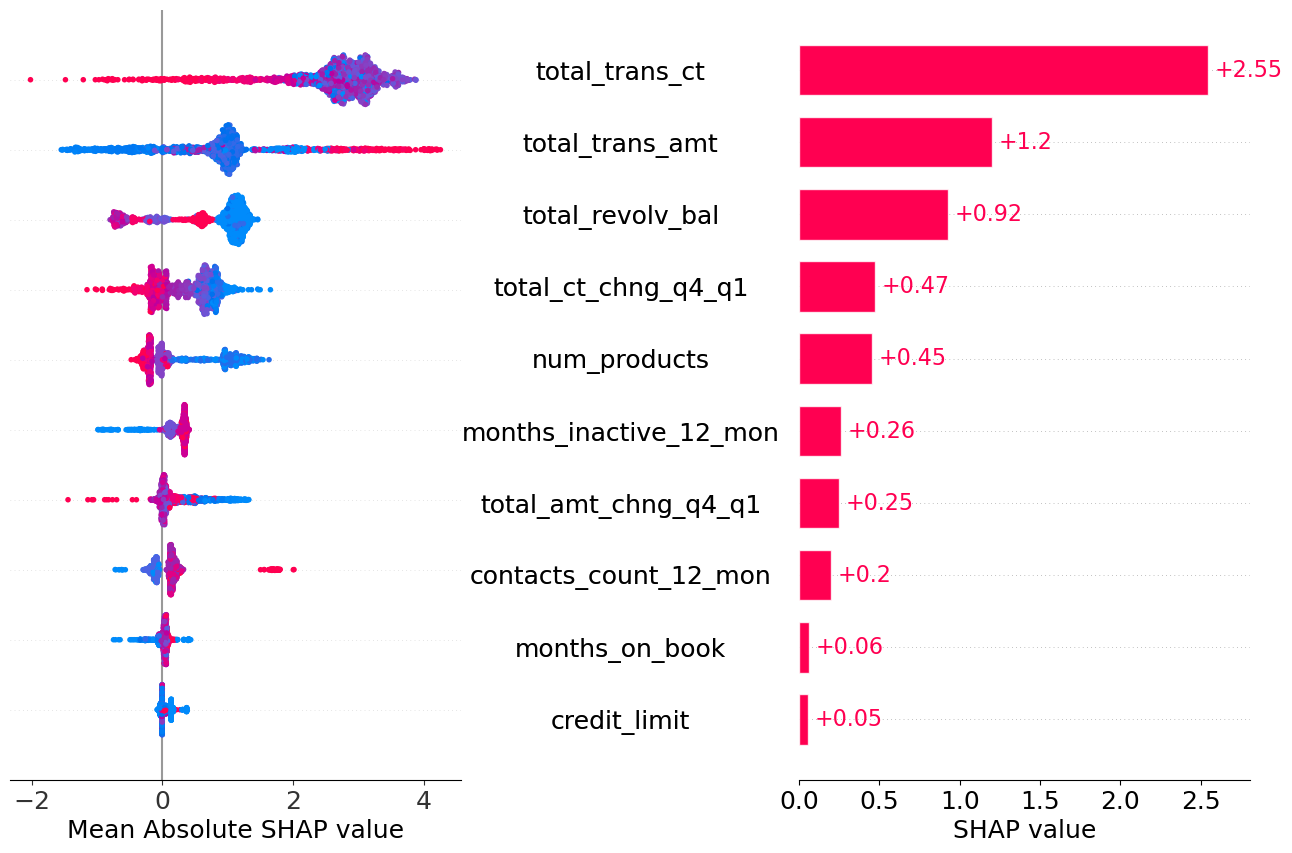

In [31]:
%%time
vzu.plot_shap_summary_plots(
    shap_explainer_values_pc,
    y_axis_annot_offset=0,
    axis_label_fontsize=18,
    y_axis_annot_fontsize=16,
    wspace=0.75,
    fig_size=(16, 10),
)

The width of the bars in the bar plot (left) indicates the importance of the features to the best model's predictions. Bar width is calculated as the average of the absolute value of the individual SHAP values for all predicted churners (customers predicted to cancel their credit card services at the bank).

The beeswarm plot (right) indicates the directionality of the individual contribution to model predictions by each feature: red indicates a higher contribution while blue indicates a lower contribution ([link](https://www.researchgate.net/publication/359141623_Prediction_of_hearing_recovery_in_unilateral_sudden_sensorineural_hearing_loss_using_artificial_intelligence)). It indicates how the most important features impact the model's predictions for churners. The order of features is based on the average of the absolute value of SHAP values for each feature and so it places more emphasis on broad average impact across all predicted churners.

### Predicted Non-Churners

Get the global SHAP values and SHAP explanation object for the predicted non-churners

In [32]:
%%time
_, shap_explainer_values_pnc = shexp.get_shap_values(
    model, df_transf_pre.query("y_pred == 0")[best_features]
)

CPU times: user 713 ms, sys: 2.06 ms, total: 715 ms
Wall time: 714 ms


Plot SHAP summary subplots

CPU times: user 145 ms, sys: 2.88 ms, total: 148 ms
Wall time: 147 ms


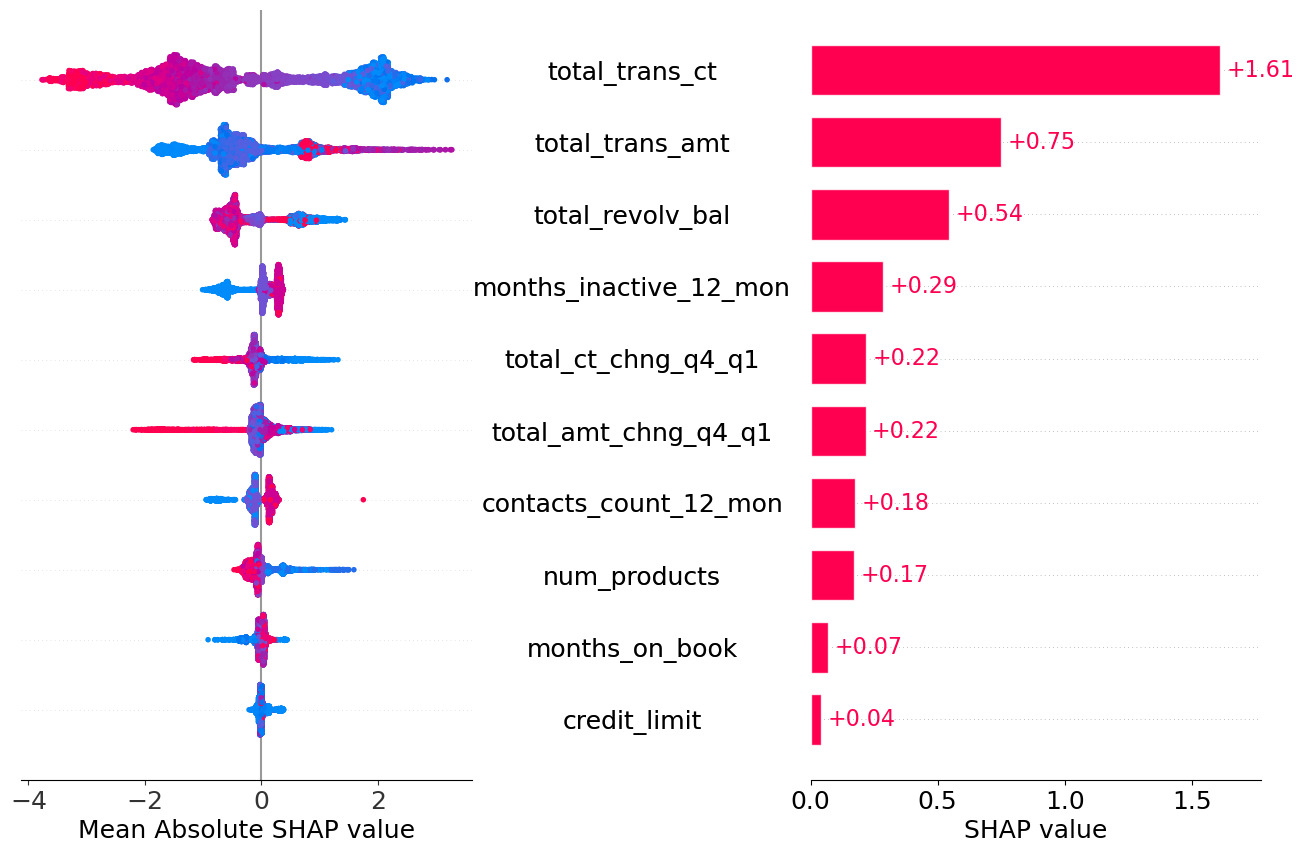

In [33]:
%%time
vzu.plot_shap_summary_plots(
    shap_explainer_values_pnc,
    y_axis_annot_offset=0,
    axis_label_fontsize=18,
    y_axis_annot_fontsize=16,
    wspace=0.75,
    fig_size=(16, 10),
)

In [34]:
%%time
_, shap_explainer_values_sc1 = shexp.get_shap_values(
    model, df_scenarios_transf_pre.query("scenario == 1")[best_features]
)

CPU times: user 62 ms, sys: 946 μs, total: 62.9 ms
Wall time: 62.3 ms


CPU times: user 81.9 ms, sys: 998 μs, total: 82.9 ms
Wall time: 82.1 ms


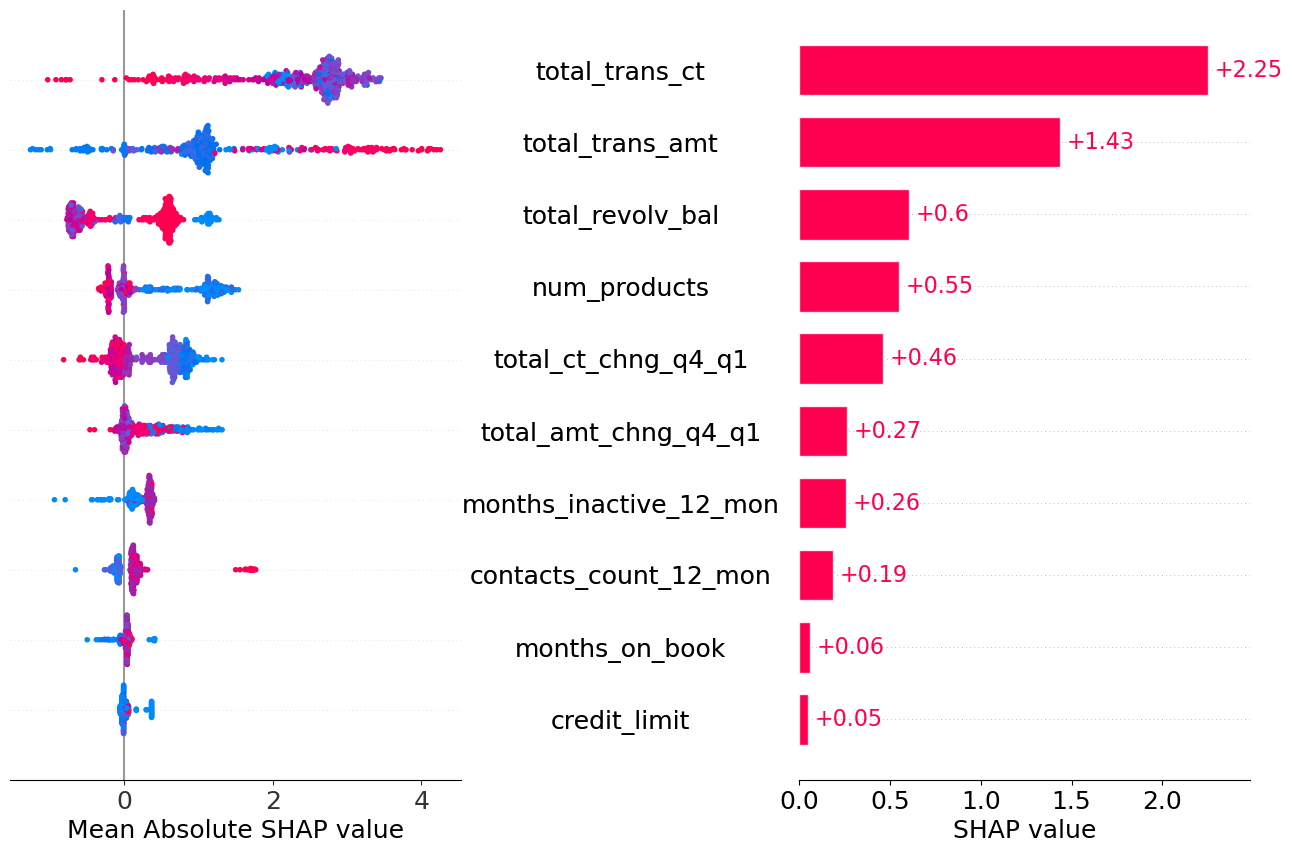

In [35]:
%%time
vzu.plot_shap_summary_plots(
    shap_explainer_values_sc1,
    y_axis_annot_offset=0,
    axis_label_fontsize=18,
    y_axis_annot_fontsize=16,
    wspace=0.75,
    fig_size=(16, 10),
)

In [36]:
%%time
_, shap_explainer_values_sc2 = shexp.get_shap_values(
    model, df_scenarios_transf_pre.query("scenario == 2")[best_features]
)

CPU times: user 107 ms, sys: 30 μs, total: 107 ms
Wall time: 107 ms


CPU times: user 85.3 ms, sys: 970 μs, total: 86.2 ms
Wall time: 85.7 ms


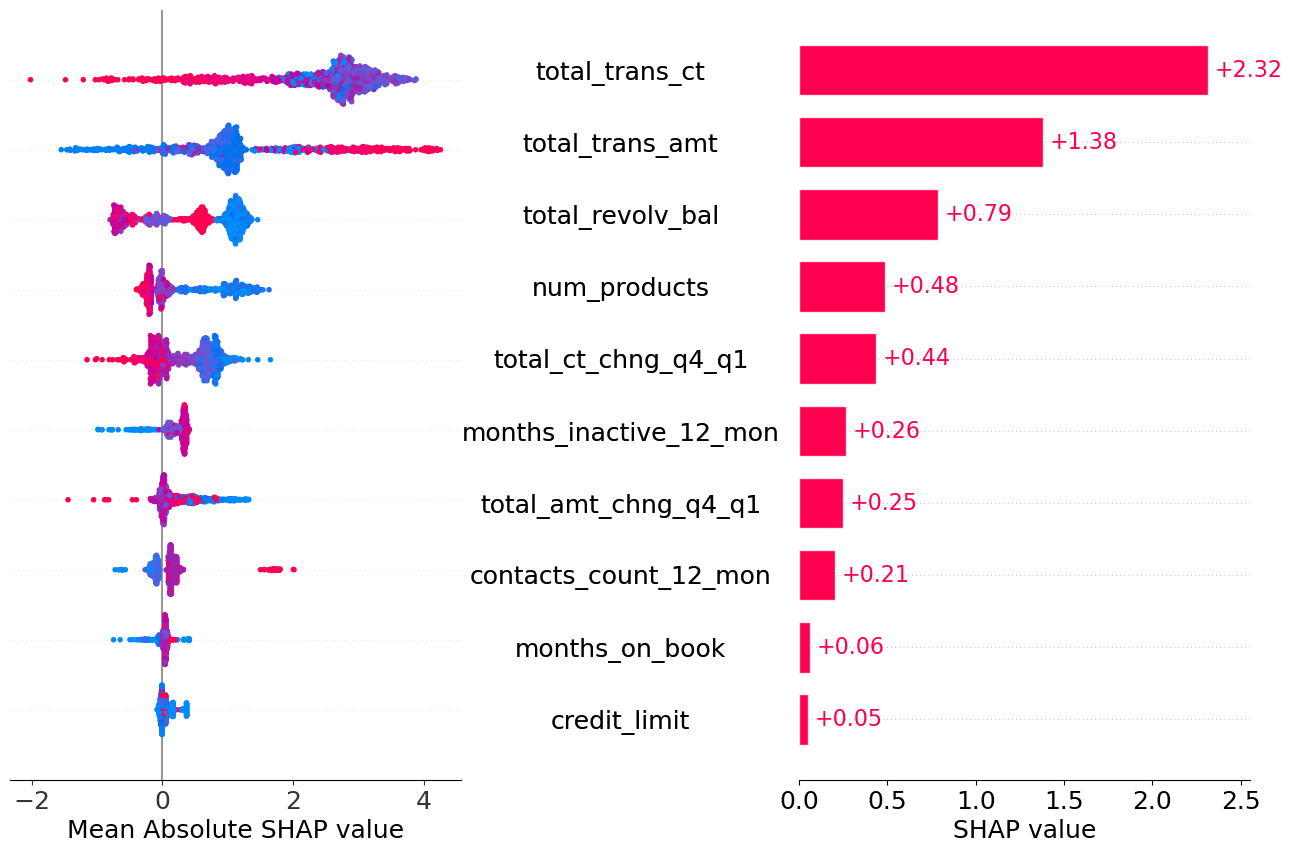

In [37]:
%%time
vzu.plot_shap_summary_plots(
    shap_explainer_values_sc2,
    y_axis_annot_offset=0,
    axis_label_fontsize=18,
    y_axis_annot_fontsize=16,
    wspace=0.75,
    fig_size=(16, 10),
)

## Conclusion